# Week 11 Classification Models - Logistic Regression and K Nearest Neighbors
The goal of this assignment is to introduce you to classification models.  Classification models used data to predict categorical data.  In the Logistic Regression mode it will predict one of two possible outcomes.  K-Nearest Neighbors will be used to make a prediction between the two possible outcomes but it can also be used to determine more than 2 possible outcomes.<br>

We will start by loading a few libraries we have already used to process our data.  The other libraries we will use will be load as we need them so you can see what is required to run the models.  Run the code cell below.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
heart = pd.read_csv("heart.csv")
heart.head()

# Display Data Structure
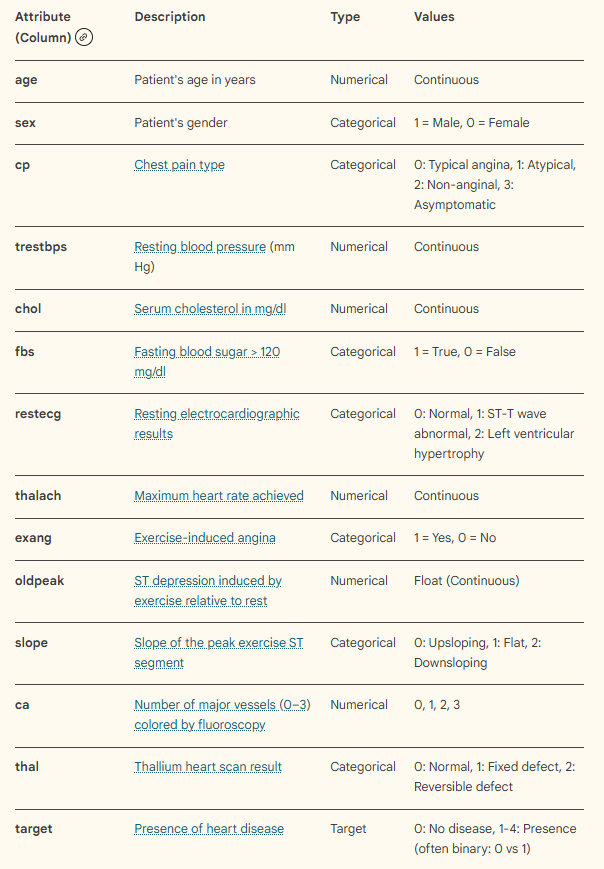

In [ ]:
heart.info()

# Change the categorical variables to string

In [ ]:
s_col = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in s_col:
    heart[col] = heart[col].astype(str)

In [ ]:
heart['target'].value_counts(normalize = True) * 100

# Split the data into train and test datasets

In [ ]:
train, test = train_test_split(heart, test_size = 0.3, random_state = 42, stratify = heart['target'])

# Check train and test dataset distribution of target values

In [ ]:
train['target'].value_counts(normalize = True) * 100

In [ ]:
test['target'].value_counts(normalize = True) * 100

# Correlation of training data set

In [ ]:
corr_matrix = train.corr(numeric_only = True)
corr_matrix

# Descriptive Statistics

In [ ]:
train.describe().T

# Q1 - Data Visualization

Create a correlation heatmap to easily view the correlation matrix.
- create the figure size 5, 5
- create the heatmap using corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5
- create the plt.title "Feature Correlation Heatmap"
- run show

# Q2 - Separate Features and Target variables for train and test datasets
- Assign 'target' from train dataset to y_train
- Assign to X_train from train dataset dropping 'target', axis = 1
- Assign 'target' from test dataset to y_test
- Assign to X_test from test dataset dropping 'target', axis = 1

# Q3 - Create a pipeline for processing Numerical data
- Assign numeric column names to num_feature
- Assign num_transformer Pipeline
- Imputer missing values with name 'imputer' with SimpleImputer strategy = 'mean'
- Scale numeric values with name 'scaler' using StandardScaler()

# Q4 - Create a pipeline for processing Categorical data
- Assign categorical column names to categorical_features
- Assign categorical_transformer Pipelin
- Imputer missing values with name 'imputer' with SimpleImputer strategy = 'most_frequent'
- OneHotEncoder with name 'onehot' with handle_unknown = 'ignore'

# Q5 - Creating a data preprocessing pipeline
- Assign preprocessor to ColumnTransformer
- num_transformer with name 'num' and the column names num_features
- cat_transformer with name 'cat' and the column names cat_features

# Q6 - Call sci-kit learn libraries
- call library from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
- call library from sklearn.linear_model import LogisticRegression
- call library from sklearn.neighbors import KNeighborsClassifier
- call library from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
- call library from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
- call library from sklearn.metrics import ConfusionMatrixDisplay

# Q7 - Create a Model for Logistic Regression and KNN
- Create a pipeline called log_pipeline
- code the name 'preprocessor' and preprocessor 
- code the name 'clf' and LogisticRegression with parameter random_state = 42.
- Create a pipeline called knn_pipeline
- code the name 'preprocessor' and preprocessor
- code the name 'clf' and KNeighborsClassifier with parameter n_neighbors = 5.

# Q8 - Cross Validation Comparison
- define the function cross_val_comparison(models)
- create a for loop with parameters name, model in models
- create the cross_val_score for model, X, y, cv = 5 assign to variable cv_scores
- create the cross_val_predict for model, X, y, cv = 5 assign to variable y_cv_pred
- create a list called target_name with 'Normal' and 'Disease'
- print(classification_report(y, y_cv_pred, target_names = target_names))
- create the cross_val_score for model, X_test, y_test, cv = 5 assign to variable cv_scores1
- create the cross_val_predict for model, X_test, y_test, cv = 5 assign to variable y_cv_pred1
- print(classification_report(y_test, y_cv_pred1, target_names = target_names))


In [ ]:



        print(f"{name}: ---------------------------------------------------------------------")
        print("Training Data set")
        print(f" Mean Accuracy: {cv_scores.mean(): .2f}")
        print(f" Std Deviation: {cv_scores.std(): .2f}\n")
       
 
 
        print("Testing Data set")
        print(f" Mean Accuracy: {cv_scores.mean(): .2f}")
        print(f" Std Deviation: {cv_scores.std(): .2f}\n")
        

cross_val_comparison(models)

# Q9 - Diagnosis: Identify Overfitting
Within the check_for_overfitting(model, name) function the following statements
- use the if statement to subtract test-acc from train_acc greater than 0.10
-  print "Result: OVERFITTING (Model is memorizing noise)"
- else
-  print "Result: GOOD GENERALIZATION"
- run the check_for_overfitting for log_pipeline and name "Logistic Regression"
- run the check_for_overfitting for knn_pipeline and name "K Nearest Neighbor"

# 

In [ ]:
def check_for_overfitting(model, name):
    model.fit(X, y)
    train_acc = model.score(X, y)
    test_acc = model.score(X_test, y_test)
    print(f"-----{name} Health Check ----")
    print(f"Training Accuracy: {train_acc: .2f}")
    print(f"Testing Accuracy: {test_acc: .2f}")
    print(f"Gap: {train_acc - test_acc: .2f}")

    print("\n")
   


# Q10 - Adjust for imbalance of the data set
- Create a Pipeline called bal_log_pipeline
- create the tuple 'preprocessor' and preprocessor
- create the tuple 'clf1' and LogisticRegression(class_weight = 'balanced', random_state = 42)
- create a Pipeline called bal_knn_pipeline
- create the tuple 'preprocessor' and preprocessor
- create the tuple 'clf1' and KNeighborsClassifer(n_neighbors = 5, weights = 'distance'))
- run the cross_val_comparison with models2 as the parameter
- run check_for_overfitting with parameters bal_log_pipeline and title "Balanced Logistic Regression"
- run check_for_overfittin with parapmetes bal_knn_pipeline and title "Balanced KNN"

In [ ]:


models2 = [('Balanced Logistic Regression', bal_log_pipeline), ('Balanced KNN', bal_knn_pipeline)]


# Function for print_confusion_matrix function

In [ ]:
def print_confusion_matrix(modelx, X, y, X_test, y_test, cv, title):
    y_cv_pred_train = cross_val_predict(modelx, X, y, cv = 5)
    print("--- "+title+": Cross-Validated Report - Training ---")
    
    cm = confusion_matrix(y, y_cv_pred_train, normalize = 'true') * 100
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap = plt.cm.Reds)
    plt.title(title+" CV Confusion Matrix - Percentages")
    plt.show()
    
    y_cv_pred_test = cross_val_predict(modelx, X_test, y_test, cv = 5)
    print("--- "+title+": Cross-Validated Report - Test---")
  
    cm = confusion_matrix(y_test, y_cv_pred_test, normalize = 'true') * 100
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title+" CV Confusion Matrix - Percentages")
    plt.show()


#  Q11 - Run Confusion Matrix for each model
- in a Code cell run print_confusion_matrix for log_pipeline for training features, training target, Testing features,and Testing target cv = 5, and "Logistic Regression", , normalize='true'
- in a new Code cell run print_confusion_matrix for knn_pipeline for training features, training target, Testing features, and testing target cv = 5, "K Nearest Neighbors"
- in a new Code cell run print_confusion_matrix for bal_log_pipeline for training features, training target, Testing features, and testing target, cv = 5, "Balanced Logistic Regression"
- in a new Code cell run print_confusion_matrix for bal_knn_pipeline for training features, training target, Testing features, and testing target, cv = 5, "Balanced K Nearest Neighbors"